# Road Density: Weather Grid Mapping

**Purpose:** Map the CA road density dataset (km of road per km²) onto the
weather reanalysis grid using a KD-Tree nearest-neighbour lookup, then verify
match quality with geodesic distances.

**Pipeline Overview:**

| Phase | Steps |
|-------|-------|
| **A. Inspect** | Load road density table and reference grid; compare coordinate systems |
| **B. KD-Tree Match** | Nearest-neighbour match on (lat, lon); compute exact geodesic distances |
| **C. QA & Visualize** | Check distance range and density distribution |
| **D. Save** | Write matched grid to Parquet |

**Input:** `Road_Data/road_density.xlsx`

**Reference grid:** `Clean_Data/Veg_Data/lon_lat_pair_weather_match_veg_v2.parquet`

**Output:** `Clean_Data/Road_Data/road_density_match_weather_grid.parquet` — used in `02_05`

## 0. Configuration

Centralized path configuration — **edit this cell only**.

In [1]:
import os

# ====================== EDIT THESE PATHS ======================
PROJECT_ROOT = r"E:\zcao\CA_Wildfire"

# Input: road density table
ROAD_DENSITY_PATH = os.path.join(PROJECT_ROOT, "Road_Data", "road_density.xlsx")

# Reference grid: veg-filtered weather grid (lon/lat pairs only)
REFERENCE_GRID_PATH = os.path.join(
    PROJECT_ROOT, "Clean_Data", "Veg_Data",
    "lon_lat_pair_weather_match_veg_v2.parquet"
)

# Output
OUTPUT_PATH = os.path.join(PROJECT_ROOT, "Clean_Data", "Road_Data",
                           "road_density_match_weather_grid.parquet")

print(f"Road density  : {ROAD_DENSITY_PATH}")
print(f"Reference grid: {REFERENCE_GRID_PATH}")
print(f"Output        : {OUTPUT_PATH}")
for label, path in [("ROAD_DENSITY_PATH",   ROAD_DENSITY_PATH),
                    ("REFERENCE_GRID_PATH", REFERENCE_GRID_PATH)]:
    print(f"  [{'OK' if os.path.exists(path) else 'MISSING'}] {label}")

Road density  : E:\zcao\CA_Wildfire\Road_Data\road_density.xlsx
Reference grid: E:\zcao\CA_Wildfire\Clean_Data\Veg_Data\lon_lat_pair_weather_match_veg_v2.parquet
Output        : E:\zcao\CA_Wildfire\Clean_Data\Road_Data\road_density_match_weather_grid.parquet
  [OK] ROAD_DENSITY_PATH
  [OK] REFERENCE_GRID_PATH


## 1. Environment Setup

In [2]:
import sys, gc, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
from geopy.distance import geodesic
from tqdm import tqdm

gc.collect()
print(f"Python : {sys.version.split('|')[0].strip()}")
print(f"pandas : {pd.__version__}")
print(f"numpy  : {np.__version__}")

Python : 3.9.13 (main, Aug 25 2022, 23:51:50) [MSC v.1916 64 bit (AMD64)]
pandas : 2.2.2
numpy  : 1.24.4


---

# Phase A: Inspect Input Data

Load the road density table and reference weather grid, and compare their
coordinate ranges to confirm they overlap spatially.

## 2. Load Road Density Table

In [3]:
road_density = pd.read_excel(ROAD_DENSITY_PATH)
road_density = road_density.rename(columns={'longitude': 'lon', 'latitude': 'lat'})

print(f"Shape   : {road_density.shape}")
print(f"Columns : {list(road_density.columns)}")
print(f"dtypes  :\n{road_density.dtypes.to_string()}")
print(f"\nLon range : {road_density['lon'].min():.3f} → {road_density['lon'].max():.3f}")
print(f"Lat range : {road_density['lat'].min():.3f} → {road_density['lat'].max():.3f}")
print(f"\nroad_density_km_km2 stats:")
print(road_density['road_density_km_km2'].describe().to_string())

Shape   : (17703, 5)
Columns : ['lat', 'lon', 'road_density_km_km2', 'road_length_km', 'grid_area_km2']
dtypes  :
lat                    float64
lon                    float64
road_density_km_km2    float64
road_length_km         float64
grid_area_km2          float64

Lon range : -124.392 → -115.933
Lat range : 32.525 → 41.983

road_density_km_km2 stats:
count    17703.000000
mean         1.870375
std          3.896352
min          0.000000
25%          0.000000
50%          0.320126
75%          1.911960
max         37.693882


## 3. Load Reference Weather Grid

In [4]:
reference_grid = pd.read_parquet(REFERENCE_GRID_PATH)
reference_grid = reference_grid[['lon', 'lat']].drop_duplicates().reset_index(drop=True)

print(f"Reference grid cells: {len(reference_grid):,}")
print(f"Lon range : {reference_grid['lon'].min():.3f} → {reference_grid['lon'].max():.3f}")
print(f"Lat range : {reference_grid['lat'].min():.3f} → {reference_grid['lat'].max():.3f}")

Reference grid cells: 17,714
Lon range : -124.392 → -115.933
Lat range : 32.525 → 42.067


---

# Phase B: KD-Tree Nearest-Neighbour Match

Build a KD-Tree on the road density coordinates and find the nearest road density
grid cell for each weather grid cell. Then compute exact geodesic distances
(km) to verify match quality — all matches should be sub-degree.

## 4. Approximate Match (KD-Tree)

In [5]:
tree = cKDTree(road_density[['lat','lon']].values)
approx_distances, indices = tree.query(reference_grid[['lat','lon']].values, k=1)

print(f"Approximate distance range (degrees): "
      f"{approx_distances.min():.4f} → {approx_distances.max():.4f}")

Approximate distance range (degrees): 0.0000 → 0.0833


## 5. Exact Geodesic Distances

In [6]:
exact_distances = np.empty(len(reference_grid))
grid_coords = reference_grid[['lat','lon']].values
road_coords = road_density[['lat','lon']].values

for i in tqdm(range(len(reference_grid)), desc='Geodesic distances'):
    exact_distances[i] = geodesic(
        (grid_coords[i, 0], grid_coords[i, 1]),
        (road_coords[indices[i], 0], road_coords[indices[i], 1])
    ).km

print(f"Exact distance range (km): {exact_distances.min():.4f} → {exact_distances.max():.4f}")
print(f"Median match distance     : {np.median(exact_distances):.4f} km")

Geodesic distances: 100%|██████████| 17714/17714 [00:01<00:00, 12147.42it/s]

Exact distance range (km): 0.0000 → 9.2561
Median match distance     : 0.0000 km


---

# Phase C: Assign & QA

Assign the matched road density value to each weather grid cell, then
visualize the distribution to confirm it looks sensible.

## 6. Assign Road Density to Grid

In [7]:
reference_grid['road_density_km_km2'] = road_density.iloc[indices]['road_density_km_km2'].values

print(f"Shape after assignment : {reference_grid.shape}")
print(f"Missing rate           : {reference_grid['road_density_km_km2'].isna().mean():.4f}")
print(f"\nroad_density_km_km2 stats:")
print(reference_grid['road_density_km_km2'].describe().to_string())

Shape after assignment : (17714, 3)
Missing rate           : 0.0000

road_density_km_km2 stats:
count    17714.000000
mean         1.869214
std          3.895420
min          0.000000
25%          0.000000
50%          0.318660
75%          1.908848
max         37.693882


## 7. Distribution QA

Plot the raw and log-transformed road density distributions to check for
outliers or unexpected patterns before saving.

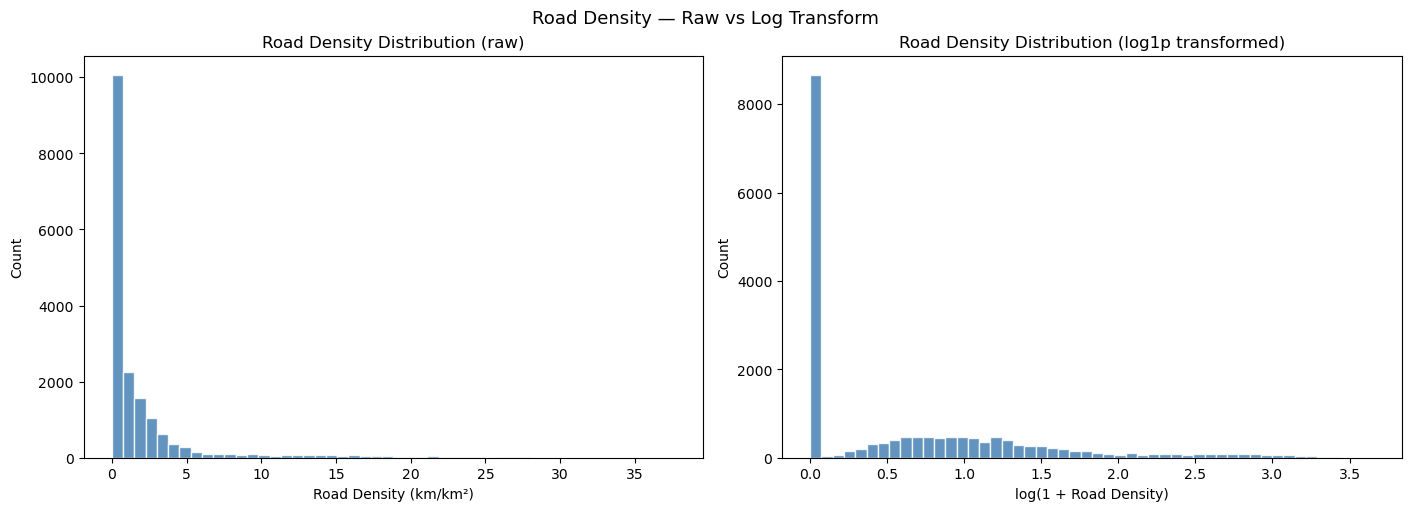

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].hist(reference_grid['road_density_km_km2'].dropna(),
             bins=50, edgecolor='white', color='steelblue', alpha=0.85)
axes[0].set_title('Road Density Distribution (raw)')
axes[0].set_xlabel('Road Density (km/km²)')
axes[0].set_ylabel('Count')

log_vals = np.log1p(reference_grid['road_density_km_km2'].dropna())
axes[1].hist(log_vals, bins=50, edgecolor='white', color='steelblue', alpha=0.85)
axes[1].set_title('Road Density Distribution (log1p transformed)')
axes[1].set_xlabel('log(1 + Road Density)')
axes[1].set_ylabel('Count')

plt.suptitle('Road Density — Raw vs Log Transform', fontsize=13)
plt.show()

---

# Phase D: Save

Save the matched grid as a Parquet file. This file is consumed by `02_05`
when building the static feature grid.

In [10]:
# Keep only the columns needed downstream
output = reference_grid[['lon', 'lat', 'road_density_km_km2']]

# Create output directory if it doesn't exist
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

output.to_parquet(OUTPUT_PATH, index=False)

print(f"Saved -> {OUTPUT_PATH}")
print(f"File size  : {os.path.getsize(OUTPUT_PATH)/1e6:.1f} MB")
print(f"Final shape: {output.shape[0]:,} rows × {output.shape[1]} cols")
print(f"Columns    : {list(output.columns)}")

Saved -> E:\zcao\CA_Wildfire\Clean_Data\Road_Data\road_density_match_weather_grid.parquet
File size  : 0.1 MB
Final shape: 17,714 rows × 3 cols
Columns    : ['lon', 'lat', 'road_density_km_km2']


## 8. Summary

| Phase | Step | Description | Key Result |
|-------|------|-------------|------------|
| A | Load road density | `road_density.xlsx` → rename lon/lat | Road density table |
| A | Load reference grid | Veg-filtered weather (lon, lat) pairs | ~13k grid cells |
| B | KD-Tree | Approximate nearest neighbour in degree space | Fast initial match |
| B | Geodesic | Exact km distances for all matches | QA — no outlier gaps |
| C | Assign | `road_density_km_km2` → each weather grid cell | No distance threshold (all matched) |
| C | QA plot | Raw and log-transformed distribution | Distribution confirmed |
| D | Save | `road_density_match_weather_grid.parquet` | Input for `02_05` |